In [1]:
import planetary_computer
from pystac_client import Client
import stackstac
import xarray as xr
import rioxarray as rio
import numpy as np
import pandas as pd
import geopandas as gpd
import os
from tqdm import tqdm
import zarr

import warnings
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import shape, box
from rasterio.enums import Resampling

import calendar

import pandas as pd
from pathlib import Path
import shutil
import time
import cv2
import gc

from requests.adapters import HTTPAdapter
from urllib3 import Retry

from pystac_client.stac_api_io import StacApiIO

from utc_src import config

root = Path.cwd()

from osgeo import gdal
# GDAL configurations

### stackstac has a default gdal env so i don't need to set these
# https://github.com/gjoseph92/stackstac/blob/main/stackstac/rio_reader.py#L36
# gdal.SetConfigOption('GDAL_HTTP_COOKIEFILE','~/cookies.txt')
# gdal.SetConfigOption('GDAL_HTTP_COOKIEJAR', '~/cookies.txt')
gdal.SetConfigOption('GDAL_DISABLE_READDIR_ON_OPEN','EMPTY_DIR')
#gdal.SetConfigOption('CPL_VSIL_CURL_ALLOWED_EXTENSIONS','TIF')
gdal.SetConfigOption('GDAL_HTTP_UNSAFESSL', 'YES')
gdal.SetConfigOption('GDAL_HTTP_MAX_RETRY', '10')
gdal.SetConfigOption('GDAL_HTTP_RETRY_DELAY', '10')

gdal.SetConfigOption('CPL_VSIL_CURL_ALLOWED_EXTENSIONS','.tif,.tiff')

In [ ]:
### re-tooled to avoid stale tokens

def build_daily_timeseries_incremental(boundary, year,dask_client,output_label):

    assets=['B02','B03','B04','B05','B06','B07','B08','B8A','B11','B12']
    epsg = boundary.crs.to_epsg()

    bbox_4326 = tuple(boundary.to_crs(4326).total_bounds)
    bbox_utm = tuple(boundary.total_bounds)

    retry = Retry(total=5, backoff_factor=2, status_forcelist=[408, 429, 500, 502, 503, 504], allowed_methods=None)

    stac_api_io = StacApiIO(max_retries=retry)

    ## define output path 
    os.makedirs(config.DATA_DIR / output_label,exist_ok=True)
    ref_zarr_path = config.DATA_DIR / output_label / f'{output_label}_daily_raw.zarr'

    done_months = set()
    if ref_zarr_path.exists():
        existing = xr.open_zarr(ref_zarr_path)
        done_months = set(pd.to_datetime(existing.time.values).month)

    ## access one month at a time
    for month in range(3,12):
        if month in done_months:
            print(f'{calendar.month_name[month]} already present, skipping')
            continue

        catalog = Client.open(
            "https://planetarycomputer.microsoft.com/api/stac/v1",
            stac_io=stac_api_io,
            modifier=planetary_computer.sign_inplace,
        )
        last = calendar.monthrange(year, month)[1] # get last day of month (30 or 31)
        items = catalog.search(
            bbox=bbox_4326,
            collections=["sentinel-2-l2a"],
            datetime=f"{year}-{month:02d}-01/{year}-{month:02}-{last:02d}T23:59:59Z" 
        ).item_collection()

        items = [i for i in items if i.properties["eo:cloud_cover"] < 80] # filter out tiles with over 80% cloud coverage

        print(f'{calendar.month_name[month]} {year}: number of images found: {len(items)}')

        # put details into a dataframe
        records = []
        for i in items:
            records.append({
                'id': i.id,
                'datetime': i.datetime,
                'tile' : i.properties.get('s2:mgrs_tile'),
                'baseline': float(i.properties.get('s2:processing_baseline'))
            })

        df = pd.DataFrame(records)
        df['datetime'] = df['datetime'].dt.floor('D')

        # if two versions of image exist, select the one with the higher processing baseline
        selected_records = df.sort_values('baseline', ascending=False).drop_duplicates(['datetime','tile'], keep='first')
        selected_ids = set(selected_records['id'])
        selected_items = [i for i in items if i.id in selected_ids]

        month_items = [planetary_computer.sign(i) for i in selected_items]
        # determine write mode based on whether zarr store already exists
        mode = 'w' if not ref_zarr_path.exists() else 'a'
        append_dim = 'time' if mode == 'a' else None
        # update time dimension length
        zarr_length = _get_zarr_length(ref_zarr_path)
     
        max_retries = 3
        for attempt in range(1,6):
        #create xarray
                try:
                    stack_ref = stackstac.stack(
                        month_items,
                        epsg=epsg,
                        resolution=10,
                        bounds=bbox_utm,
                        assets=assets,
                        resampling=Resampling.bilinear)
                    
                    
                    stack_scl = stackstac.stack(
                        month_items,
                        epsg=epsg,
                        resolution=10,
                        bounds=bbox_utm,
                        assets=['SCL'],
                        fill_value=0,
                        resampling=Resampling.nearest) # scl band is categorical
                    
                    scaled_10m = _mask_and_scale(data=stack_ref,scl=stack_scl,month_items=month_items)

                    ## ensure uniform time chunk sizes
                    scaled_10m.chunk({'time':1,'band':-1,'y':1024,'x':1024}).to_zarr(ref_zarr_path,mode=mode, append_dim=append_dim)

                    print(f'{calendar.month_name[month]} successfully written')
                    break  ## exit retry loop
                    
                ### catch server side errors e.g. http response code 503, 403
                except Exception as e:
                    print(f'attempt {attempt} failed: {e}')
                    
                    ## if this was first month delete zarr store entirely
                    if zarr_length == 0:
                        if ref_zarr_path.exists():
                            shutil.rmtree(ref_zarr_path)
                            print('deleted zarr')
                    ## otherwise truncate to before failed month attempt
                    else:
                        store = zarr.open(ref_zarr_path,mode='r+')

                        store['reflectance'].resize((zarr_length,*store['reflectance'].shape[1:]))
                        store['time'].resize((zarr_length,))
                        zarr.consolidate_metadata(ref_zarr_path) 
                        print(f'truncated zarr to length {zarr_length}')
                    
                    if attempt < (max_retries+1):
                        dask_client.restart()  ## restart workers in case that was cause of error
                        wait = 30 * attempt
                        print(f'waiting {wait}s before retrying {calendar.month_name[month]}')
                        time.sleep(wait)
                        # reset zarr variables
                        mode = 'w' if not ref_zarr_path.exists() else 'a'
                        append_dim = 'time' if mode == 'a' else None
                        zarr_length = _get_zarr_length(ref_zarr_path)
                        
                    else:
                        print(f'{calendar.month_name[month]} failed after {max_retries} tries')
                        print(f'Restarting process to resume writing {calendar.month_name[month]}')
                        return

In [ ]:
def view_available_dates_per_year(boundary, year):

    epsg = boundary.crs.to_epsg()

    bbox_4326 = tuple(boundary.to_crs(4326).total_bounds)
   

    #boundary_polygon = gpd.GeoDataFrame(geometry=[box(*bbox_utm)], crs=f"EPSG:{epsg}")
    retry = Retry(total=5, backoff_factor=2, status_forcelist=[408, 429, 500, 502, 503, 504], allowed_methods=None)

    stac_api_io = StacApiIO(max_retries=retry)

    catalog = Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        stac_io=stac_api_io,
        modifier=planetary_computer.sign_inplace,
    )

    query = {"eo:cloud_cover":{"lt":50}} 

    items = catalog.search(
        bbox=bbox_4326,
        collections=["sentinel-2-l2a"],
        datetime=f"{year}-03-01/{year}-11-30",
        query= query 
    ).item_collection()
    print(f'{year}: number of images found: {len(items)}')

    # put details into a dataframe
    records = []
    for i in items:
        records.append({
            'id': i.id,
            'datetime': i.datetime,
            'tile' : i.properties.get('s2:mgrs_tile'),
            'baseline': float(i.properties.get('s2:processing_baseline'))
        })

    df = pd.DataFrame(records)
    df['datetime'] = df['datetime'].dt.floor('D')

    # if two versions of image exist, select the one with the higher processing baseline
    selected_records = df.sort_values('baseline', ascending=False).drop_duplicates(['datetime','tile'], keep='first')
    

    return selected_records

In [14]:
### confirmed: stackstac does NOT automatically apply scale and offset for sentinel-2

def test_scale(boundary, year):
    
    assets=['B02','B03','B04','B05','B06','B07','B08','B8A','B11','B12']
    epsg = boundary.crs.to_epsg()

    bbox_4326 = tuple(boundary.to_crs(4326).total_bounds)
   
  
    bbox_utm = tuple(boundary.total_bounds)
    #boundary_polygon = gpd.GeoDataFrame(geometry=[box(*bbox_utm)], crs=f"EPSG:{epsg}")
    retry = Retry(total=5, backoff_factor=2, status_forcelist=[408, 429, 500, 502, 503, 504], allowed_methods=None)

    stac_api_io = StacApiIO(max_retries=retry)

    catalog = Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        stac_io=stac_api_io,
        modifier=planetary_computer.sign_inplace,
    )

    query = {"eo:cloud_cover":{"lt":20}} 

    items = catalog.search(
        bbox=bbox_4326,
        collections=["sentinel-2-l2a"],
        datetime=f"{year}-03-01/{year}-11-30",
        query= query 
    ).item_collection()
    print(f'{year}: number of images found: {len(items)}')


    stack_ref = stackstac.stack(
                            items[0],
                            epsg=epsg,
                            resolution=10,
                            bounds=bbox_utm,
                            assets=assets,
                            resampling=Resampling.bilinear)

    return stack_ref

In [ ]:
t = test_scale(boundary=boundary,year=2024)    #428 down to 133

c:\Users\roseh\miniconda3\envs\utc2-env\Lib\site-packages\pystac_client\item_search.py:243: DoesNotConformTo: Server does not conform to QUERY
  warnings.warn(DoesNotConformTo("QUERY"))


2024: number of images found: 133


In [19]:
boundary = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')
all_d = []
for y in [2017,2018,2021]:
    d = view_available_dates_per_year(boundary=boundary,year=y)
    all_d.append(d)

pd.concat(all_d).to_csv(root / 'data' / 'all_sentinel_dates_2017_2018_2021_nocloudfilter.csv')

2017: number of images found: 331
2018: number of images found: 424
2021: number of images found: 436


In [ ]:
def mask_and_scale(data,scl,month_df,month_items):
    stack = data.drop_attrs().reset_coords(drop=True).astype('float32')
    stack  = stack.assign_coords(time=stack['time'].dt.floor('D')) # convert timestamp to just the day

    stack_scl = scl.drop_attrs().reset_coords(drop=True).astype('uint8')
    stack_scl = stack_scl.assign_coords(time=stack_scl['time'].dt.floor('D')).squeeze('band')

    scl_values = [0,1,3, 8, 9, 10, 11]   # no water mask (6) and no dark pixels mask (2)
    mask = ~stack_scl.isin(scl_values)

    stack_masked = stack.where(mask)

    # apply offset if baseline >= 4.0
    baseline_lookup = {i.id: float(i.properties['s2:processing_baseline']) for i in month_items}
    baselines = xr.DataArray([baseline_lookup[item_id] for item_id in data['id'].values],dims=('time',),coords={'time':stack.time})
    offset_mask = (baselines >= 4.0).astype('float32')

    # baselines = (data['s2:processing_baseline'].astype('float32')).assign_coords({'time':stack.time})
    # offset_mask = (baselines >= 4.0).astype('float32')
    
    scaled = (stack_masked - (offset_mask * 1000)) / 10000  
    ### TODO: should really apply offset and scale factors from metadata instead of hardcoding constants
    # https://clearsky.vision/knowledge/sentinel2-scaling-harmonization

    # scaled = scaled.clip(min=0) 
    if len(month_df['tile'].unique()) > 1:
        # merge images from different tiles taken on same day
        scaled = scaled.groupby('time').median(dim='time',skipna=True) 
        
    scaled.name = 'reflectance'
    return scaled

def _get_zarr_length(ref_zarr_path):
        if ref_zarr_path.exists():
            g = zarr.open_group(str(ref_zarr_path),mode='r')
            return int(g['time'].shape[0])
        else:
            return 0
   

def build_daily_timeseries_incremental(boundary, year,dask_client,output_label,assets=['B02','B03','B04','B05','B06','B07','B08','B8A','B11','B12']):

    epsg = boundary.crs.to_epsg()

    bbox_4326 = tuple(boundary.to_crs(4326).total_bounds)
    bbox_utm = tuple(boundary.total_bounds)

    #boundary_polygon = gpd.GeoDataFrame(geometry=[box(*bbox_utm)], crs=f"EPSG:{epsg}")
    retry = Retry(total=5, backoff_factor=2, status_forcelist=[408, 429, 500, 502, 503, 504], allowed_methods=None)

    stac_api_io = StacApiIO(max_retries=retry)

    catalog = Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        stac_io=stac_api_io,
        modifier=planetary_computer.sign_inplace,
    )

    #query = {"eo:cloud_cover":{"lt":20}} 

    items = catalog.search(
        bbox=bbox_4326,
        collections=["sentinel-2-l2a"],
        datetime=f"{year}-03-01/{year}-11-30"
        #query= query 
    ).item_collection()
    print(f'{year}: number of images found: {len(items)}')

    # put details into a dataframe
    records = []
    for i in items:
        records.append({
            'id': i.id,
            'datetime': i.datetime,
            'tile' : i.properties.get('s2:mgrs_tile'),
            'baseline': float(i.properties.get('s2:processing_baseline'))
        })

    df = pd.DataFrame(records)
    df['datetime'] = df['datetime'].dt.floor('D')

    # if two versions of image exist, select the one with the higher processing baseline
    selected_records = df.sort_values('baseline', ascending=False).drop_duplicates(['datetime','tile'], keep='first')
    selected_ids = set(selected_records['id'])
    selected_items = [i for i in items if i.id in selected_ids]

    ## define output path 
    os.makedirs(config.DATA_DIR / output_label,exist_ok=True)
    ref_zarr_path = config.DATA_DIR / output_label / f'{output_label}_daily_raw.zarr'

    done_months = set()
    if ref_zarr_path.exists():
        existing = xr.open_zarr(ref_zarr_path)
        done_months = set(pd.to_datetime(existing.time.values).month)
  
    ## access one month at a time
    for month in range(3,12):
        if month in done_months:
            print(f'{calendar.month_name[month]} already present, skipping')
            continue
    
        print(f'{calendar.month_name[month]}')
        month_df = selected_records[selected_records['datetime'].dt.month == month]
        if len(month_df) == 0:
            print(f'no images')
            continue
        else:
            print(f'{len(month_df)} images')

        month_items = [planetary_computer.sign(i) for i in selected_items
               if i.datetime.month == month]
        # determine write mode based on whether zarr store already exists
        mode = 'w' if not ref_zarr_path.exists() else 'a'
        append_dim = 'time' if mode == 'a' else None
        # update time dimension length
        zarr_length = _get_zarr_length(ref_zarr_path)
     

        max_retries = 3
        for attempt in range(1,6):
        #create xarray
                try:
                    stack_ref = stackstac.stack(
                        month_items,
                        epsg=epsg,
                        resolution=10,
                        bounds=bbox_utm,
                        assets=assets,
                        resampling=Resampling.bilinear)
                    
                    
                    stack_scl = stackstac.stack(
                        month_items,
                        epsg=epsg,
                        resolution=10,
                        bounds=bbox_utm,
                        assets=['SCL'],
                        resampling=Resampling.nearest) # scl band is categorical
                    
                    scaled_10m = mask_and_scale(data=stack_ref,scl=stack_scl,month_df=month_df,month_items=month_items)

                    ## ensure uniform time chunk sizes
              
                    scaled_10m.chunk({'time':1,'band':-1,'y':1024,'x':1024}).to_zarr(ref_zarr_path,mode=mode, append_dim=append_dim)

                    print(f'{calendar.month_name[month]} successfully written')
                    break  ## exit retry loop
                    
                ### catch server side errors e.g. http response code 503
                except Exception as e:
                    print(f'attempt {attempt} failed: {e}')
                    
                    ## if this was first month delete zarr store entirely
                    if zarr_length == 0:
                        if ref_zarr_path.exists():
                            shutil.rmtree(ref_zarr_path)
                            print('deleted zarr')
                    ## otherwise truncate to before failed month attempt
                    else:
                        store = zarr.open(ref_zarr_path,mode='r+')

                        store['reflectance'].resize((zarr_length,*store['reflectance'].shape[1:]))
                        store['time'].resize((zarr_length,))
                        zarr.consolidate_metadata(ref_zarr_path) 
                        print(f'truncated zarr to length {zarr_length}')
                    
                    if attempt <= max_retries:
                        dask_client.restart()  ## restart workers in case that was cause of error
                        wait = 30 * attempt
                        print(f'waiting {wait}s before retrying {calendar.month_name[month]}')
                        time.sleep(wait)
                        # reset zarr variables
                        mode = 'w' if not ref_zarr_path.exists() else 'a'
                        append_dim = 'time' if mode == 'a' else None
                        zarr_length = _get_zarr_length(ref_zarr_path)
                        ## resign items in case that was the cause of the error 
                        month_items = [planetary_computer.sign(i) for i in selected_items if i.datetime.month == month]
                    else:
                        print(f'{calendar.month_name[month]} failed after {max_retries} tries')
                        print(f'The API connection went flaky. Restart process to resume writing {calendar.month_name[month]}')
                        return

                      
def get_gradient(im) :
        # Calculate the x and y gradients using Sobel operator
        grad_x = cv2.Sobel(im,cv2.CV_32F,1,0,ksize=3)
        grad_y = cv2.Sobel(im,cv2.CV_32F,0,1,ksize=3)
        # Combine the two gradients
        grad = cv2.addWeighted(np.absolute(grad_x), 0.5, np.absolute(grad_y), 0.5, 0)

        return grad



def coregister_images(data_10m,downscale,zarr_path):

    ## downsize image and do a first pass warp, then a warm-started warp at full resolution

    warp_mode = cv2.MOTION_TRANSLATION
    #criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 1000, 1e-6)
    criteria_small= (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 100, 1e-4)
    criteria_full = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 200, 1e-6)

    nir_all = data_10m.sel(band='B08').persist()
    reference_image = nir_all.median(dim='time', skipna=True).to_numpy()
    # replace nans with zeroes
    reference_image = np.where(np.isfinite(reference_image), reference_image, 0)
    ref_gradient_full = get_gradient(reference_image)
    # downsize before calculating gradient
    ref_small = cv2.resize(reference_image, None, fx=1/downscale, fy=1/downscale, interpolation=cv2.INTER_AREA)
    ref_gradient_small = get_gradient(ref_small)

    time = data_10m.shape[0]
    bands_10 = data_10m.shape[1]
    h10, w10 = data_10m.shape[2], data_10m.shape[3]

    #aligned_10m = np.full((time, bands_10, h10, w10), np.nan, dtype=np.float32)
    #success = np.zeros(time, dtype=bool)

    mode = 'w' 
    append_dim = None

    qc = []
    for i in tqdm(range(time)):
        aligned = np.full((1, bands_10, h10, w10), np.nan, dtype=np.float32)
        # single time slice, convert to numpy
        nir = nir_all.isel(time=i).to_numpy()
        # replace nans with zeroes, get full scale gradient
        nir_full = np.where(np.isfinite(nir), nir, 0).astype(np.float32)
        nir_gradient_full = get_gradient(nir_full)
        ## downsize and get coarse gradient
        nir_small = cv2.resize(nir_full, None, fx=1/downscale, fy=1/downscale, interpolation=cv2.INTER_AREA)
        nir_gradient_small = get_gradient(nir_small)

        # get valid masks for full size and coarse versions
        valid_full = np.isfinite(nir).astype('uint8')
        valid_small = cv2.resize(valid_full, None, fx=1/downscale, fy=1/downscale, interpolation=cv2.INTER_NEAREST)

        #nir_gradient = get_gradient(nir_small)
        warp_matrix = np.eye(2, 3, dtype=np.float32)

        try:
            ## coarse version first
            _, warp_matrix = cv2.findTransformECC(
                templateImage=ref_gradient_small, inputImage=nir_gradient_small, warpMatrix=warp_matrix, motionType=warp_mode, criteria=criteria_small, inputMask=valid_small)
            # rescale warp matrix
            warp_matrix[:, 2] *= downscale

            # now full scale version
            _, warp_matrix = cv2.findTransformECC(
                templateImage=ref_gradient_full, inputImage=nir_gradient_full, warpMatrix=warp_matrix, motionType=warp_mode, criteria=criteria_full, inputMask=valid_full)

        except cv2.error:
            print(f'Failed to converge at timestep {i}, skipping')
            continue

        ## revert suspiciously large warps
        if abs(warp_matrix[0,2]) > 5 or abs(warp_matrix[1,2]) > 5: 
            warp_matrix = np.eye(2,3,dtype=np.float32)
            print(f'warp too large, reverting')
            qc.append(data_10m.time.values[i])
        
        # apply to 10m stack
        im10 = data_10m.isel(time=i).to_numpy()
        #valid_10m = np.isfinite(im10[6]).astype('uint8')
        valid_10m_warped = cv2.warpAffine(valid_full, warp_matrix, (w10, h10),
                                           flags=cv2.INTER_NEAREST + cv2.WARP_INVERSE_MAP,
                                           borderMode=cv2.BORDER_CONSTANT, borderValue=0).astype('bool')
        for j in range(bands_10):
            w = cv2.warpAffine(im10[j], warp_matrix, (w10, h10),
                               flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
                               borderMode=cv2.BORDER_CONSTANT, borderValue=0)
            w[~valid_10m_warped] = np.nan
            aligned[0, j] = w

        #success[i] = True

    # rebuild DataArrays with matched time coords
        aligned_time = xr.DataArray(aligned,
                                    coords={'time': [data_10m.time.values[i]],
                                            'band': data_10m.band,
                                            'y': data_10m.y, 'x': data_10m.x},
                                    dims=['time', 'band', 'y', 'x'],name='reflectance')

        aligned_time.to_zarr(zarr_path, mode=mode,append_dim=append_dim)
        
        mode = 'a'
        append_dim = 'time'
    
    print(qc)

    
    
   

    
 



In [ ]:
from dask.distributed import Client as da_client
from dask.distributed import LocalCluster

cluster = LocalCluster(
    n_workers=4,              
    threads_per_worker=1,     
    memory_limit='6GB',       
)
dask_client = da_client(cluster)
dask_client

In [ ]:
output_label = 'nyc22'
year = 2022

# with dask client:
# 52 mintues to write march - july
# 32 minutes for august - november

## no dask client:
# 50 minutes to write march - june
# 48 minutes to write july - september
# 17 minutes to write october - november

b = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')
#os.makedirs(root / 'data' / siteyear,exist_ok=True)
build_daily_timeseries_incremental(b,year=year,output_label=output_label)

c:\Users\roseh\miniconda3\envs\utc2-env\Lib\site-packages\pystac_client\item_search.py:243: DoesNotConformTo: Server does not conform to QUERY
  warnings.warn(DoesNotConformTo("QUERY"))


2022: number of images found: 213
March already present, skipping
April already present, skipping
May already present, skipping
June already present, skipping
July already present, skipping
August already present, skipping
September already present, skipping
October
22 images


October: 100%|██████████| 18147/18147 [12:16<00:00, 24.63it/s] 


October successfully written
November
19 images


November: 100%|██████████| 13338/13338 [05:06<00:00, 43.52it/s] 

November successfully written


### Coregister Images

In [3]:
b = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')

In [12]:
siteyear = 'nyc20'

ref_10m = xr.open_zarr(root / 'data' / output_label/ f'{output_label}_daily_raw.zarr')['reflectance']
ref_10m = ref_10m.rio.write_crs(26918).rio.set_spatial_dims(x_dim='x',y_dim='y').rio.write_coordinate_system()

In [13]:
out_path = root / 'data' / output_label/ f'{output_label}_daily_raw_aligned.zarr'
coregister_images(ref_10m,downscale=4,zarr_path=out_path)

 24%|██▎       | 13/55 [02:05<04:40,  6.67s/it]

Failed to converge at timestep 12, skipping


100%|██████████| 55/55 [11:42<00:00, 12.77s/it]

[]


In [16]:
## remove nonaligned file once aligned is complete
import shutil
shutil.rmtree(root /'data' / output_label / f'{output_label}_daily_raw.zarr')

#### Derive Spectral Indices

In [ ]:
def safe_div(num, den):
    # below the floor the denominator is noise/invalid and result is NaN.
    # prevents absurdly high index values due to tiny denominator
    floor=1e-3
    return num / den.where(den > floor)

def derive_indices(ref,output_label):

   
    ## put bands and time together; make spatial chunks smaller
    ref = ref.chunk(chunks={'time': -1, 'band': -1, 'y': 256, 'x': 256})
   
    blue  = ref.sel(band="B02")
    green = ref.sel(band="B03")
    red   = ref.sel(band="B04")
    re1   = ref.sel(band="B05")
    re2   = ref.sel(band="B06")
    re3   = ref.sel(band="B07")
    nir   = ref.sel(band="B08")
    nir_a = ref.sel(band="B8A")
    sw1   = ref.sel(band="B11")
    sw2   = ref.sel(band="B12")

    ds = xr.Dataset()
    

    # moisture
    ds["s2wi"]  = safe_div(re1 - sw2, re1 + sw2)
    ds["ndmi"]  = safe_div(nir - sw1, nir + sw1)
 

    ## vegetation/chlorophyll
    ds["ndre2"] = safe_div(nir_a - re2, nir_a + re2)
    # ds["ireci"] = safe_div(re3 - red, safe_div(re1, re2,floor=denom_floor),floor=denom_floor)
    # ds["gndvi"] = safe_div(nir - green, nir + green,floor=denom_floor)
    ds["grvi"]  = safe_div(green - red, green + red)
    ds["psri"]  = safe_div(red - blue, re2)
    ds["tdvi"]  = 1.5 * ((nir - red) / (nir**2 + red + 0.5) ** 0.5)
    #ds["evi2"]   = 2.5 * (nir - red) / (nir + 2.4 * red + 1.0)
	
    # bare/built up
    ds["nbr"]   = safe_div(nir - sw2, nir + sw2)
    ds["bsi"]   = safe_div((sw1 + red) - (nir + blue), (sw1 + red) + (nir + blue))

    ## clip to physical range
    nd = ["s2wi","ndmi","ndre2","nbr","grvi","bsi"]
    for k in nd:
        ds[k] = ds[k].clip(-1, 1)
  
    all_indices = ds.to_array(dim='band').transpose('time','band', 'y', 'x')

    time_chunk = -1  ### keep all time steps in the same chunk for later time dimension aggregations
    band_chunk = 1   ### put bands in separate chunks because they are only used one at a time later.
    spatial_chunk = 256

    all_data = xr.concat([ref,all_indices],dim='band').astype('float32').chunk({'time':time_chunk,'band':band_chunk,'y':spatial_chunk,'x':spatial_chunk})
    all_data.name = 'variables'
    
    encoding = {'variables':{'compressor': zarr.Blosc(cname='zstd',clevel=3,shuffle=2)}}
    all_data.to_zarr(root / 'data' / output_label / f'{output_label}_daily_bandsandindices.zarr',mode='w',encoding=encoding)
 

In [7]:
## read in aligned reflectance data
output_label = 'nyc18'
ref = xr.open_zarr(root / 'data' / output_label / f'{output_label}_daily_raw_aligned.zarr')['reflectance']


boundary = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')

In [8]:
derive_indices(ref=ref,boundary=boundary,output_label=output_label)

### Calculate Seasonal Statistics

In [ ]:
from dask.distributed import Client as da_client
from dask.distributed import LocalCluster

cluster = LocalCluster(
    n_workers=4,              
    threads_per_worker=1,     
    memory_limit='6GB',       
)
dask_client = da_client(cluster)
dask_client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 22.35 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:56124,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:56149,Total threads: 1
Dashboard: http://127.0.0.1:56153/status,Memory: 5.59 GiB
Nanny: tcp://127.0.0.1:56127,


2026-09-25 14:59:29,439 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle f5451bd2c91ad774b42f587101b7ca7f initialized by task ('rechunk-merge-rechunk-transfer-0900a7d19594ccd29a6000979f9e5a66', 0, 0, 6, 8, 0, 4, 6, 8) executed on worker tcp://127.0.0.1:56143
2026-09-25 14:59:31,947 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle fd388e27acef5e6ddf140a625833f21e initialized by task ('rechunk-merge-rechunk-transfer-0900a7d19594ccd29a6000979f9e5a66', 0, 0, 8, 6, 0, 4, 8, 6) executed on worker tcp://127.0.0.1:56146
2026-09-25 14:59:33,572 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle bff4d65fdcef4bd76057cf36fa568d51 initialized by task ('rechunk-merge-rechunk-transfer-0900a7d19594ccd29a6000979f9e5a66', 0, 0, 7, 6, 0, 4, 7, 6) executed on worker tcp://127.0.0.1:56146
2026-09-25 14:59:33,574 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle aa13e29d9e10b1ec67929ef74c2b3bc5 initialized by task ('rechunk-merge-rechunk-transfer-0900a7d19594ccd29a60

In [9]:
siteyear = 'nyc18'
sc = 256
all_data = xr.open_zarr(root / 'data' / siteyear / f'{siteyear}_daily_bandsandindices.zarr')['variables']
#all_data = all_data.chunk({'time':-1,'band':-1,'y':sc,'x':sc})
#bytes = all_data.chunks[0][0] * all_data.chunks[1][0] *  all_data.chunks[2][0] *  all_data.chunks[3][0] *  4
band_chunks = 6  
bytes = all_data.chunks[0][0] * band_chunks *  all_data.chunks[2][0] *  all_data.chunks[3][0] *  4
mb = bytes/1e6

print(f'MB per chunk: {mb}')

MB per chunk: 91.226112


In [12]:
aggregate_to_seasons(output_label='nyc18')

season


c:\Users\roseh\miniconda3\envs\utc2-env\Lib\site-packages\distributed\client.py:3371: UserWarning: Sending large graph of size 28.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


spring


c:\Users\roseh\miniconda3\envs\utc2-env\Lib\site-packages\distributed\client.py:3371: UserWarning: Sending large graph of size 28.97 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


summer


...

c:\Users\roseh\miniconda3\envs\utc2-env\Lib\site-packages\distributed\client.py:3371: UserWarning: Sending large graph of size 28.97 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


spring_delta


c:\Users\roseh\miniconda3\envs\utc2-env\Lib\site-packages\distributed\client.py:3371: UserWarning: Sending large graph of size 24.61 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


fall_delta


c:\Users\roseh\miniconda3\envs\utc2-env\Lib\site-packages\distributed\client.py:3371: UserWarning: Sending large graph of size 24.61 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [11]:
## can delete raw_aligned file at this point
def aggregate_to_seasons(output_label):
    

    out_path = root / 'data' / output_label / f'{output_label}_seasonalstats.zarr'
    if os.path.exists(out_path):
        shutil.rmtree(out_path)

    all_data = xr.open_zarr(root / 'data' / output_label / f'{output_label}_daily_bandsandindices.zarr')['variables']
    #all_data = all_data.chunk({'time':-1,'band':-1,'y':256,'x':256})
    band_chunk = all_data.sizes['band']
    spatial_chunk = all_data.chunksizes['y'][0]

    ## set vars for first zarr write
    encoding = {'features':{'chunks':(band_chunk,spatial_chunk,spatial_chunk),
                                            'compressor': zarr.Blosc(cname='zstd',clevel=3,shuffle=2)}}
    mode = 'w'
    append_dim = None

    ### clip to city boundary
    boundary = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')
    epsg = boundary.crs.to_epsg()
    all_data = all_data.rio.write_crs(epsg).rio.set_spatial_dims(x_dim='x',y_dim='y').rio.write_coordinate_system()
    all_data = all_data.rio.clip(boundary.geometry)

    windows = {"season": (3, 11),"spring": (3, 5),"summer": (6, 8),"fall": (9, 11)}
    for wname, (m1,m2) in windows.items():
        print(wname)
        season = all_data.sel(time=all_data.time.dt.month.isin(range(m1,m2+1)))

        # aggregations

        q = season.quantile([0.25, 0.5, 0.75], dim="time", skipna=True)
        p25 = q.sel(quantile=0.25).drop_vars("quantile")
        p50 = q.sel(quantile=0.5).drop_vars('quantile')
        p75 = q.sel(quantile=0.75).drop_vars("quantile")
        iqr = p75 - p25

        stats = {'median':p50,
                'iqr':iqr}
        
        ## add new band coordinate to each stat array
        segments = []
        for st in stats:
            a = stats[st]
            new_band = (a['band'].astype('str') + f'_{wname}_{st}').astype(object)
            a = a.assign_coords({'band':new_band})
            segments.append(a)

        all_segs = xr.concat(segments,dim='band')

        all_segs = all_segs.to_dataset(name='features').astype('float32')
        all_segs = all_segs.chunk({'band':band_chunk,'y':spatial_chunk,'x':spatial_chunk})

        all_segs.to_zarr(out_path,mode=mode,encoding=encoding,append_dim = append_dim)

        ## reset vars for zarr appends
        mode = 'a'
        append_dim = 'band'
        encoding = None

    ## get delta of medians for march/april - may/june and august/sept - october/nov
    month_deltas = {'spring_delta':(6,4),'fall_delta':(9,11)}
    for dname,(start,end) in month_deltas.items():
        print(dname)
        m_1 = all_data.sel(time=all_data.time.dt.month.isin([start,start-1])).median(dim='time',skipna=True)
        m_2 = all_data.sel(time=all_data.time.dt.month.isin([end,end-1])).median(dim='time',skipna=True)

        delta = m_1 - m_2

        new_bands = (delta['band'].astype('str') + f'_{dname}').astype(object)
        delta = delta.assign_coords({'band':new_bands})

        delta = delta.to_dataset(name='features').astype('float32')
        delta = delta.chunk({'band':band_chunk,'y':spatial_chunk,'x':spatial_chunk})

        delta.to_zarr(out_path,mode=mode,encoding=encoding,append_dim = append_dim)

    




    

In [13]:
windows = {"season": (3, 11,'growing season'),"spring": (3, 5,'spring'),"summer": (6, 8,'summer'),"fall": (9, 11,'fall')}
    
    
for wname, (m1,m2,m3) in windows.items():
    print(m1,m2,m3)

3 11 growing season
3 5 spring
6 8 summer
9 11 fall


In [ ]:
### add season to season deltas for index means
# summer - spring, summer - autumn
## indices and relative measures more transfer stable than raw reflectance

In [14]:
t = xr.open_zarr(root / 'data' / output_label / f'{output_label}_seasonalstats.zarr')['features']

t.chunksizes

Frozen({'band': (18, 18, 18, 18, 18, 18, 18, 18, 18, 18), 'y': (256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 78), 'x': (256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 62)})

In [15]:
t.band.values

array(['B02_season_median', 'B03_season_median', 'B04_season_median',
       'B05_season_median', 'B06_season_median', 'B07_season_median',
       'B08_season_median', 'B8A_season_median', 'B11_season_median',
       'B12_season_median', 's2w_season_median', 'ndm_season_median',
       'ndr_season_median', 'grv_season_median', 'psr_season_median',
       'tdv_season_median', 'nbr_season_median', 'bsi_season_median',
       'B02_season_iqr', 'B03_season_iqr', 'B04_season_iqr',
       'B05_season_iqr', 'B06_season_iqr', 'B07_season_iqr',
       'B08_season_iqr', 'B8A_season_iqr', 'B11_season_iqr',
       'B12_season_iqr', 's2w_season_iqr', 'ndm_season_iqr',
       'ndr_season_iqr', 'grv_season_iqr', 'psr_season_iqr',
       'tdv_season_iqr', 'nbr_season_iqr', 'bsi_season_iqr',
       'B02_spring_median', 'B03_spring_median', 'B04_spring_median',
       'B05_spring_median', 'B06_spring_median', 'B07_spring_median',
       'B08_spring_median', 'B8A_spring_median', 'B11_spring_median',
    

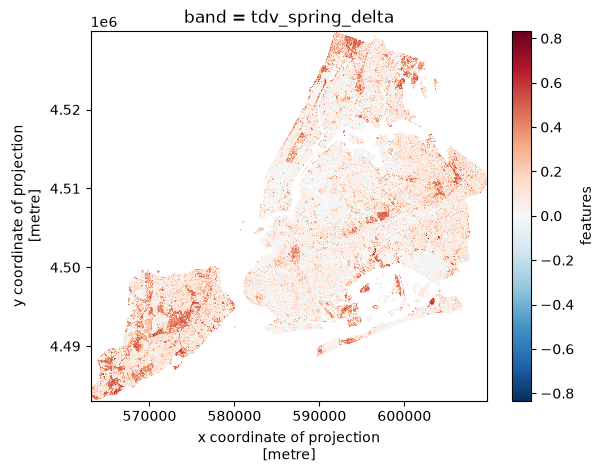

In [16]:
t.sel(band='tdv_spring_delta').plot()  #22.4, -20.2     tdvi: -1.4 - 1.3

#### archive

In [11]:
siteyear = 'nyc17'

ref_10m = xr.open_zarr(root / 'data' / siteyear / f'{siteyear}_daily_raw_10m.zarr')['__xarray_dataarray_variable__']
ref_10m = ref_10m.rio.write_crs(26918).rio.set_spatial_dims(x_dim='x',y_dim='y').rio.write_coordinate_system()
ref_20m = xr.open_zarr(root / 'data' / siteyear / f'{siteyear}_daily_raw_20m.zarr')['__xarray_dataarray_variable__']
ref_20m = ref_20m.rio.write_crs(26918).rio.set_spatial_dims(x_dim='x',y_dim='y').rio.write_coordinate_system()

# # didn't clip properly before oops
b_buffered = b.buffer(3000)
ref_10m = ref_10m.rio.clip(geometries=b_buffered.geometry)
ref_20m = ref_20m.rio.clip(geometries=b_buffered.geometry)


In [ ]:
# b_buffered = b.buffer(3000)
# ref_10m_clipped = ref_10m.rio.clip(geometries=b_buffered.geometry)

ref_10m.isel(time=7,band=2).plot()

In [14]:
# TODO: move to download function
def drop_sparse_scenes(data_10m,data_20m,percentile):
    valid_fraction = data_20m.isel(band=0).notnull().mean(dim=['y','x'])

    threshold = np.percentile(valid_fraction.values,percentile)

    keep_times = valid_fraction >= np.round(threshold,2)
    num_dropped = (~keep_times).sum().values

    times = data_20m.time.values[keep_times]

    print(f'dropping {num_dropped} scenes')

    return data_10m.sel(time=times), data_20m.sel(time=times) 

In [15]:
# drop scenes with percent valid data less than 20th percentile 
ref_10m, ref_20m = drop_sparse_scenes(ref_10m, ref_20m,percentile=20)

dropping 4 scenes


In [16]:
ref_10m_aligned, ref_20m_aligned = coregister_paired(data_10m=ref_10m,data_20m=ref_20m)

c:\Users\roseh\miniconda3\envs\utc2-env\Lib\site-packages\distributed\client.py:3371: UserWarning: Sending large graph of size 21.43 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
  0%|          | 0/40 [00:00<?, ?it/s]c:\Users\roseh\miniconda3\envs\utc2-env\Lib\site-packages\distributed\client.py:3371: UserWarning: Sending large graph of size 20.96 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
  2%|▎         | 1/40 [00:08<05:30,  8.47s/it]c:\Users\roseh\miniconda3\envs\utc2-env\Lib\site-packages\distributed\

In [17]:
ref_10m_aligned.to_netcdf(root / 'data' / siteyear / f'{siteyear}_daily_10m_aligned_buffered.nc')
ref_20m_aligned.to_netcdf(root / 'data' / siteyear / f'{siteyear}_daily_20m_aligned_buffered.nc')

In [2]:
ref_10m_aligned = xr.open_dataarray(root / 'data' / 'nyc21' / 'nyc21_daily_10m_aligned.nc')
ref_20m_aligned = xr.open_dataarray(root / 'data' / 'nyc21' / 'nyc21_daily_20m_aligned.nc')

In [5]:
ref_10m_aligned.sizes

Frozen({'time': 39, 'band': 4, 'y': 4686, 'x': 4670})

In [ ]:
# also save as numpy arrays to input into dsen2
np.save(root / 'data' / 'nyc21' / 'nyc21_daily_10m_aligned_numpy.npy',ref_10m_aligned.values)
np.save(root / 'data' / 'nyc21' / 'nyc21_daily_20m_aligned_numpy.npy',ref_20m_aligned.values)

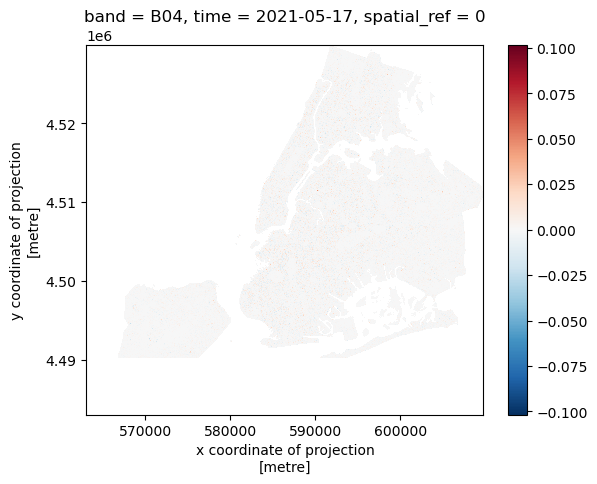

In [34]:
diff = ref_10m.isel(band=2,time=9) - ref_10m_aligned.isel(band=2,time=9)

diff.plot()

In [ ]:
#### previous versions


def crop_and_scale(data,scl,boundary,df,selected_items):
    stack = data.rio.clip(geometries=boundary.geometry).drop_attrs().reset_coords(drop=True).astype('float32')
    

    if scl is not None:
        stack_scl = scl.rio.clip(geometries=boundary.geometry).drop_attrs().reset_coords(drop=True).astype('uint8')
        stack_scl = stack_scl.assign_coords(time=stack_scl['time'].dt.floor('D'))

    stack  = stack.assign_coords(time=stack['time'].dt.floor('D')) # convert timestamp to just the day
   
    # offset (if baseline < 4) and scale
    baselines = xr.DataArray([float(i.properties['s2:processing_baseline']) for i in selected_items],dims=('time',),coords={'time':stack.time})
    offset_mask = (baselines < 4.0).astype('float32') ## if baseline < 4, offset of 1000 will be added before scale factor

    scaled = (stack + offset_mask * 1000) / 10000  

    scaled = scaled.clip(min=0) 

    if len(df['tile'].unique()) > 1:
        # merge images from different tiles taken on same day
        scaled = scaled.groupby('time').median(dim='time',skipna=True) 
        
        if scl is not None:
            stack_scl = stack_scl.groupby('time').max(dim='time')

    if scl is not None:
        return scaled, stack_scl
    else:
        return scaled


def build_daily_timeseries(boundary, year,res,siteyear,scl=True,assets=['B02','B03','B04','B08','B05','B06','B07','B8A','B11','B12']):

    epsg = boundary.crs.to_epsg()

    bbox_4326 = tuple(boundary.to_crs(4326).total_bounds)
    bbox_utm = tuple(boundary.total_bounds)

    boundary_polygon = gpd.GeoDataFrame(geometry=[box(*bbox_utm)], crs=f"EPSG:{epsg}")

    catalog = Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=planetary_computer.sign_inplace,
    )

    query = {"eo:cloud_cover":{"lt":20}} 

    items = catalog.search(
        bbox=bbox_4326,
        collections=["sentinel-2-l2a"],
        datetime=f"{year}-03-01/{year}-11-30",
        query= query 
    ).item_collection()
    print(f'{year}: number of images found: {len(items)}')

    # put details into a dataframe
    records = []
    for i in items:
        records.append({
            'id': i.id,
            'datetime': i.datetime,
            'tile' : i.properties.get('s2:mgrs_tile'),
            'baseline': float(i.properties.get('s2:processing_baseline'))
        })

    df = pd.DataFrame(records)
    df['datetime'] = df['datetime'].dt.floor('D')

    # if two versions of image exist, select the one with the higher processing baseline
    selected_records = df.sort_values('baseline', ascending=False).drop_duplicates(['datetime','tile'], keep='first')
    selected_ids = set(selected_records['id'])
    selected_items = [i for i in items if i.id in selected_ids]

   
    #create xarray
    stack_ref = stackstac.stack(
        selected_items,
        epsg=epsg,
        resolution=res,
        bounds=bbox_utm,
        assets=assets,
        resampling=Resampling.bilinear)
    
    if scl:
        stack_scl = stackstac.stack(
            selected_items,
            epsg=epsg,
            resolution=res,
            bounds=bbox_utm,
            assets=['SCL'],
            resampling=Resampling.nearest) # scl band is categorical
        
        scaled_10m, scl_10m = crop_and_scale(data=stack_ref,scl=stack_scl,boundary=boundary_polygon,df=df,selected_items=selected_items)

        scaled_10m.chunk({'time':1,'band':-1,'y':1024,'x':1024}).to_zarr(root / 'data' / siteyear / f'{siteyear}_daily_raw_{res}m.zarr',mode='w')
        
        scl_10m.chunk({'time':1,'band':-1,'y':1024,'x':1024}).to_zarr(root / 'data' / siteyear / f'{siteyear}_daily_scl_{res}m.zarr',mode='w')
    
    else:

        scaled_20m = crop_and_scale(data=stack_ref,scl=None,boundary=boundary_polygon,df=df,selected_items=selected_items)

        scaled_20m.chunk({'time':1,'band':-1,'y':512,'x':512}).to_zarr(root / 'data' / siteyear / f'{siteyear}_daily_raw_{res}m.zarr',mode='w')




def coregister_paired(data_10m, data_20m):
    
    nir_10m = xr.where(np.isfinite(data_10m.isel(band=3)), data_10m.isel(band=3), 0)
    reference_image = nir_10m.median(dim='time', skipna=True).to_numpy()
    ref_gradient = get_gradient(reference_image)

    time = data_10m.shape[0]
    bands_10 = data_10m.shape[1]
    bands_20 = data_20m.shape[1]
    h10, w10 = data_10m.shape[2], data_10m.shape[3]
    h20, w20 = data_20m.shape[2], data_20m.shape[3]

    aligned_10m = np.full((time, bands_10, h10, w10), np.nan, dtype=np.float32)
    aligned_20m = np.full((time, bands_20, h20, w20), np.nan, dtype=np.float32)
    success = np.zeros(time, dtype=bool)

    warp_mode = cv2.MOTION_TRANSLATION
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 1000, 1e-6)

    for i in tqdm(range(time)):
        # calculate warp from 10m NIR
        nir = xr.where(np.isfinite(data_10m.isel(time=i, band=3)),
                       data_10m.isel(time=i, band=3), 0).to_numpy()
        nir_gradient = get_gradient(nir)
        warp_matrix = np.eye(2, 3, dtype=np.float32)

        try:
            _, warp_matrix = cv2.findTransformECC(
                ref_gradient, nir_gradient, warp_matrix, warp_mode, criteria
            )
        except cv2.error:
            print(f'Failed to converge at timestep {i}, skipping')
            continue

        # apply to 10m stack
        valid_10m = np.isfinite(data_10m.isel(time=i, band=3).to_numpy()).astype('uint8')
        valid_10m_warped = cv2.warpAffine(valid_10m, warp_matrix, (w10, h10),
                                           flags=cv2.INTER_NEAREST + cv2.WARP_INVERSE_MAP,
                                           borderMode=cv2.BORDER_CONSTANT, borderValue=0).astype('bool')
        im10 = data_10m.isel(time=i).to_numpy()
        for j in range(bands_10):
            w = cv2.warpAffine(im10[j], warp_matrix, (w10, h10),
                               flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
                               borderMode=cv2.BORDER_CONSTANT, borderValue=0)
            w[~valid_10m_warped] = np.nan
            aligned_10m[i, j] = w

        # scale warp matrix for 20m — translation components are halved
        warp_matrix_20m = warp_matrix.copy()
        warp_matrix_20m[0, 2] /= 2  # x translation
        warp_matrix_20m[1, 2] /= 2  # y translation

        valid_20m = np.isfinite(data_20m.isel(time=i, band=0).to_numpy()).astype('uint8')
        valid_20m_warped = cv2.warpAffine(valid_20m, warp_matrix_20m, (w20, h20),
                                           flags=cv2.INTER_NEAREST + cv2.WARP_INVERSE_MAP,
                                           borderMode=cv2.BORDER_CONSTANT, borderValue=0).astype('bool')
        im20 = data_20m.isel(time=i).to_numpy()
        for j in range(bands_20):
            w = cv2.warpAffine(im20[j], warp_matrix_20m, (w20, h20),
                               flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
                               borderMode=cv2.BORDER_CONSTANT, borderValue=0)
            w[~valid_20m_warped] = np.nan
            aligned_20m[i, j] = w

        success[i] = True

    # rebuild DataArrays with matched time coords
    aligned_10m = xr.DataArray(aligned_10m[success],
                                coords={'time': data_10m.time.values[success],
                                        'band': data_10m.band,
                                        'y': data_10m.y, 'x': data_10m.x},
                                dims=['time', 'band', 'y', 'x'])

    aligned_20m = xr.DataArray(aligned_20m[success],
                                coords={'time': data_20m.time.values[success],
                                        'band': data_20m.band,
                                        'y': data_20m.y, 'x': data_20m.x},
                                dims=['time', 'band', 'y', 'x'])

    return aligned_10m, aligned_20m
